# Webpage UI Element Classification
## Multi-label Classification from Full-Page Screenshot Images

The objective of this project is the classification of UI element types from full webpage screenshot images retrieved from the synthetically generated Roboflow Website Screenshots dataset [Website Screenshots](https://public.roboflow.com/object-detection/website-screenshots), composed of 1206 unique screenshots from over 1000 of the world's top websites. 


This leads to a supervised multi-label classification with 8 output binary labels per image defined in the datasets specs:

| Label | Description |
|---|---|
| `button` | Navigation links, tabs, interactive controls |
| `field` | Form input fields |
| `heading` | Text enclosed in `<h1>`–`<h6>` tags |
| `iframe` | Ads and third-party embedded content |
| `image` | `<img>`, `<svg>`, `<video>` tags and icons |
| `label` | Text labelling form fields |
| `link` | Inline textual `<a>` tags |
| `text` | All other text content |


Each screenshot can have multiple active labels simultaneously.

### Motivation

The understanding of which UI elements are visually present in a webpage has direct applications in different circumstances and domains. Specifically, the ability to predict UI elements from pixels alone is relevant for the following examples:

- **Robotic Process Automation (RPA):** RPA tools are designed to *"capture the execution of routines previously performed by a human user on the interface of a computer system, and then emulate their enactment in place of the user"* [Agostinelli et al., 2019]. Identifying which UI elements are visually present (e.g. buttons, fields, links, etc.) is a prerequisite for any agent operating without HTML access. 

- **Accessibility auditing:** *"the automated system does not have access to any meta-data about the user interface, such as view hierarchies or accessibility tags, or if this information is missing or incompletely defined, as is often the case."* [Wu et al., 2021]. This means that many applications simply don't provide enough of these metadata, making this kind of detection a good alternative for WCAG (Web Content Accessibility Guidelines) compliance checking.

- **Web information extraction:** Extracting structured data from web pages is challenging due to *"the unstructured nature of textual data and the diverse layout patterns of the web documents."* [Wang et al., 2022]. Classifying which UI element types are visually present is a key first step in any extraction pipeline.


#### References
- Wu, J., Zhang, X., Nichols, J., & Bigham, J. P. (2021). Screen Parsing: Towards Reverse Engineering of UI Models from Screenshots. *UIST '21*. https://doi.org/10.1145/3472749.3474763
- Agostinelli, S., Marrella, A., & Mecella, M. (2019). Research Challenges for Intelligent Robotic Process Automation. *BPM 2019 Workshops*. https://doi.org/10.1007/978-3-030-37453-2_2
- Wang, Q., et al. (2022). WebFormer: The Web-page Transformer for Structure Information Extraction. *WWW '22*. https://doi.org/10.1145/3485447.3512032

## Set Up

In [4]:
# Import libraries
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import MDS
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from sklearn.metrics import (hamming_loss, f1_score, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from tqdm import tqdm

# ── Force CPU only (prevents Metal GPU hang on Apple Silicon) ─────────────────
tf.config.set_visible_devices([], 'GPU')
print("GPU disabled — running on CPU")

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")

GPU disabled — running on CPU
TensorFlow : 2.16.2
NumPy      : 1.26.4


In [5]:
# Configuration of global constants
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Folders path
DATA_DIR = 'data/raw'
EMB_DIR  = 'embeddings'
FIG_DIR  = 'figures'

# Create folders if not done yet
os.makedirs(EMB_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# 8 UI element types
CLASSES    = ['button', 'field', 'heading', 'iframe', 'image', 'label', 'link', 'text']

# For ResNet50, it expects images of 224x224 pixels
IMG_SIZE   = (224, 224)

# Process images in groups of 32
BATCH_SIZE = 32

print("Directories:")
print(f"  Data       : {DATA_DIR}")
print(f"  Embeddings : {EMB_DIR}")
print(f"  Figures    : {FIG_DIR}")
print(f"\nClasses ({len(CLASSES)}): {CLASSES}")
print(f"Image size  : {IMG_SIZE}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Random seed : {RANDOM_SEED}")

Directories:
  Data       : data/raw
  Embeddings : embeddings
  Figures    : figures

Classes (8): ['button', 'field', 'heading', 'iframe', 'image', 'label', 'link', 'text']
Image size  : (224, 224)
Batch size  : 32
Random seed : 42


## 1. Data Description and Visualization

- Data loading & deduplication ← already done in cell 6
- Class distribution bar chart ← cell 8 just started
- Label co-occurrence heatmap
- Cardinality histogram
- Sample image grid

### 1.1 Data loading and deduplication

In [8]:
# Load and deduplicate: when downloaded, Roboflow export shows 2412 images rather than 1206
# Both copies of images have identical pixels and labels, so it doesn't make sense to keep both.

dfs = {} # empty dictionary to store one df per split

# loops thorugh each folder in the dataset to read the csv files
for split in ['train', 'valid', 'test']:
    df = pd.read_csv(os.path.join(DATA_DIR, split, '_classes.csv'))
    df.columns = df.columns.str.strip() # removes any accidental whitespace from column names
    df['domain'] = df['filename'].apply(lambda x: x.split('_png')[0]) # extract the domain name from the filename to identify duplicates
    df['split'] = split # adds a column recording which split the image belongs to (train, valid or test)
    df = df.drop_duplicates(subset='domain').reset_index(drop=True) # drops duplicates
    # adds the full path to each image file so later code can open it directly
    df['filepath'] = df['filename'].apply(
        lambda x: os.path.join(DATA_DIR, split, x)
    )
    dfs[split] = df # stores the cleaned df in the dictionary
    print(f"{split:6s}: {len(df):4d} images") 

# convenience variables
train_df = dfs['train']
valid_df = dfs['valid']
test_df  = dfs['test']

# merges all three splits in one df for operations that need all images at once
all_df   = pd.concat(dfs.values(), ignore_index=True)

print(f"\nTotal : {len(all_df)} unique images")
print(f"Labels: {CLASSES}")

train :  844 images
valid :  241 images
test  :  121 images

Total : 1206 unique images
Labels: ['button', 'field', 'heading', 'iframe', 'image', 'label', 'link', 'text']


### 1.2 Class distribution Bar Plot

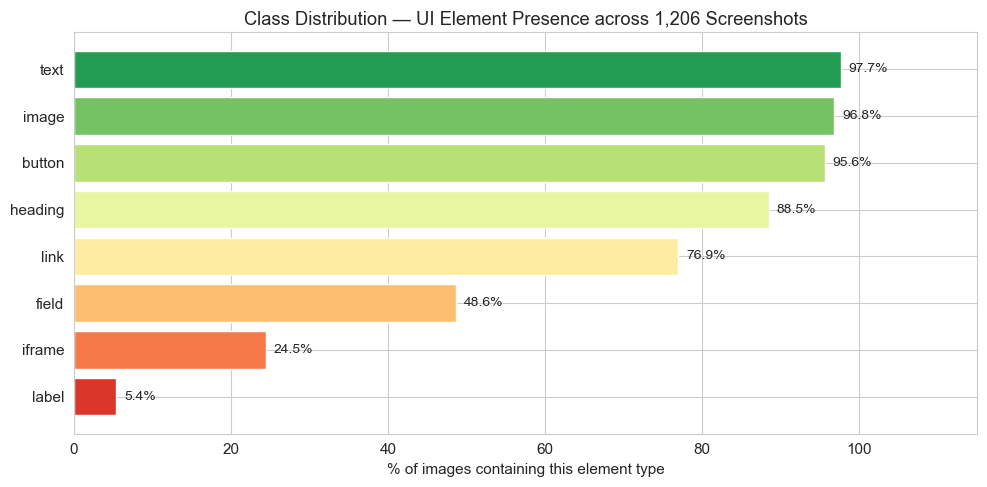


Most common : text  (97.7%)
Least common: label (5.4%)
Imbalance ratio: 18x


In [10]:
counts = all_df[CLASSES].sum().sort_values() # sums then sorts each class column for all rows
pcts   = counts / len(all_df) * 100 # converts raw counts to percentages

# creates the figure with horizontal bar charts
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index, pcts.values,
               color=sns.color_palette('RdYlGn', len(CLASSES)))
ax.set_xlabel('% of images containing this element type')
ax.set_title('Class Distribution — UI Element Presence across 1,206 Screenshots')
ax.set_xlim(0, 115)
for bar, pct in zip(bars, pcts.values):
    ax.text(pct + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout() # automatically adjusts spacing to not cut off anything
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight') # so I can save the plot for the presentation later on
plt.show()

print(f"\nMost common : text  ({pcts['text']:.1f}%)")
print(f"Least common: label ({pcts['label']:.1f}%)")
print(f"Imbalance ratio: {pcts['text']/pcts['label']:.0f}x")

The bar plot for class distribution shows a **strong imbalance** among the 8 UI element types:
- `text` (97.7%), `image` (96.8%) and `button` (95.6%) are present in nearly all screenshots, reflecting how these elements are the ones that we naturally find in most websites;
- headings and links are also frequent elements, although not as pervasive as the previous categories;
- `field` (48.6%) shows a more balanced distribution, it's close to a balanced binary splits;
- `iframe` (24.5%) and `label` (5.4%) are the least common elements, as they are typically used only in specific interface contexts (e.g. embedding external content such videos, maps or advs for iframes, describe a form control like login pages, sign-up pages, contact pages for labels).

This imbalance already tells us that the accuracy as a metric will be misleading for this model and more appropriate evaluation metrics will be needed, and class weighting is necessary to prevent the model from ignoring `label` and `iframe` during training.

### 1.3 Co-Occurrence Heatmap

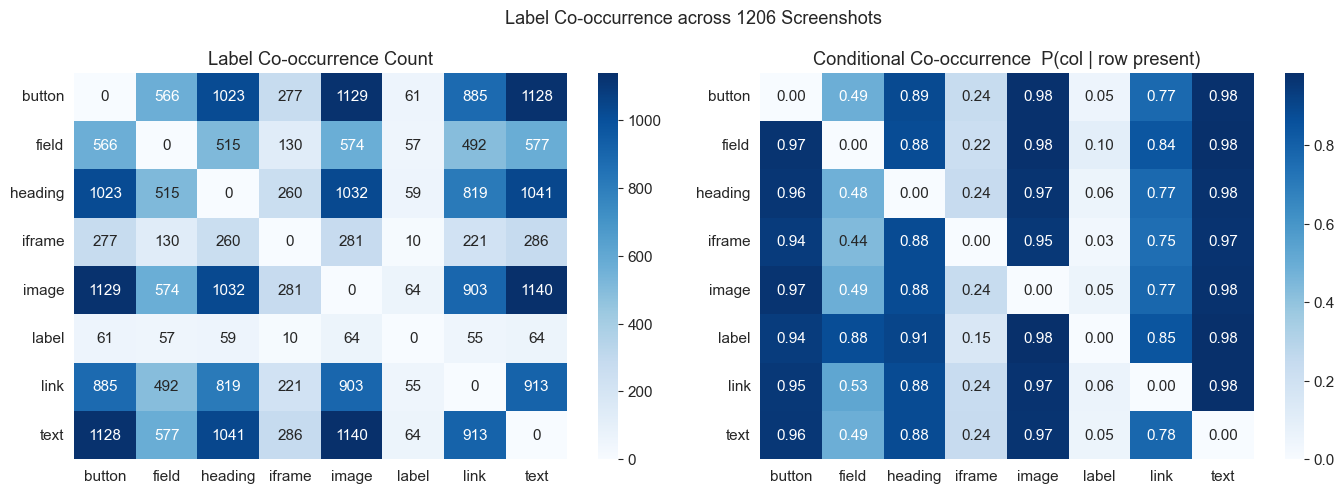

In [13]:
y_all = all_df[CLASSES].values.astype(float) # extracts the binary label matrxi from df, 1206x8 array where each row is an image and each column is a class (0 or 1)
cooc  = y_all.T @ y_all # matrix multiplication of the transposed label matrix with itself, producing an 8x8 martrix where entry [i, j] counts how many images have both classes active simultaneously
np.fill_diagonal(cooc, 0) # sets the diagonal to zero, otherwise cooc[i, i] would fill it with how many times it co-occurs with itself (class frequency)

# normalizes each row by the total count of that class, converting raw counts to conditional probabilities
cooc_norm = cooc / (all_df[CLASSES].sum().values[:, None] + 1e-8) 

# one figure row counts, one for conditional probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# draws the left heatmap with raw integer count
sns.heatmap(cooc.astype(int), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Label Co-occurrence Count')

# draws the right heatmap with conditional probabilities
sns.heatmap(cooc_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Conditional Co-occurrence  P(col | row present)')

plt.suptitle('Label Co-occurrence across 1206 Screenshots', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()

The co-occurrence heatmaps reveal how UI element types relate to each other across all the available screenshots. 

The **raw counts** on the left shows that the highest counts involve `button`, `image` and `text`, something that it's not surprising at all after observing the bar plot and being aware of their presence almost everywhere, so these large numbers say more about individual class frequency than about genuine association.


The **conditional probabilities** on the right are more informative because they show actual association. In particular:
- `button`, `image` and `text` show uniformly high conditional probabilities across all rows (0.95–0.98), this confirms that they occur together basically in very other element because they are present in almost every screenshot regardless.

- `label` column is the lowest across all the rows (0.03–0.10), meaning that even when other elements are present, `label` is rarely there. This makes `label` the most context-specific element.

- `iframe` column is similarly low (0.22–0.24), reflecting that third-party embedded content appears only in specific page types.

- An asymmetry appears between `field` and `label`, having that P(field | label present) = 0.88 but P(label | field present) = 0.10. This means that when a page has visible form labels it almost always also has fields, but the reverse scenario is not true, so many pages have input fields without any visible text labels next to them.

### 1.4 Label Cardinality Histogram

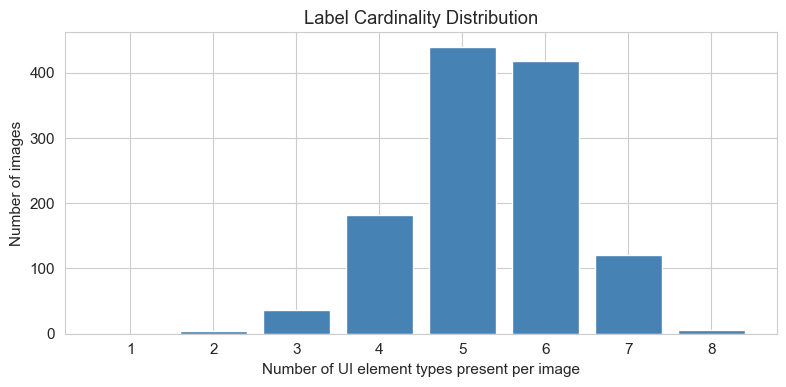

Mean  : 5.34 labels per image
Median: 5.00
Min   : 2
Max   : 8


In [16]:
cardinality = all_df[CLASSES].sum(axis=1) # sums all columns for each image to show how many classes each image has

fig, ax = plt.subplots(figsize=(8, 4))

# draws a histogram of the cardinality values
ax.hist(cardinality, bins=range(1, 10), align='left',
        color='steelblue', edgecolor='white', rwidth=0.8)
ax.set_xlabel('Number of UI element types present per image')
ax.set_ylabel('Number of images')
ax.set_title('Label Cardinality Distribution')
ax.set_xticks(range(1, 9))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cardinality_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

# prints summary statistics
print(f"Mean  : {cardinality.mean():.2f} labels per image")
print(f"Median: {cardinality.median():.2f}")
print(f"Min   : {cardinality.min():.0f}")
print(f"Max   : {cardinality.max():.0f}")

The histogram shows that most screenshots have between 4 and 6 UI element types at the same time, with a peak at 5 and 6 labels, and a mean cardinality of 5.34 and a median of 5, confirming that the distribution is approximately symmetric around 5.

No image has fewer than 2 labels, which makes sense because even the simplest webpage will have at least text and some structural element. On the other hand, only a few of the images have all the 8 labels simultaneously.

This high average cardinality confirms that this is a multi-label problem because, on average, each screenshot has more than half of the possible element types present at the same time, so predicting a single lable per image would not be enough.

### 1.5 Sample Image Grid

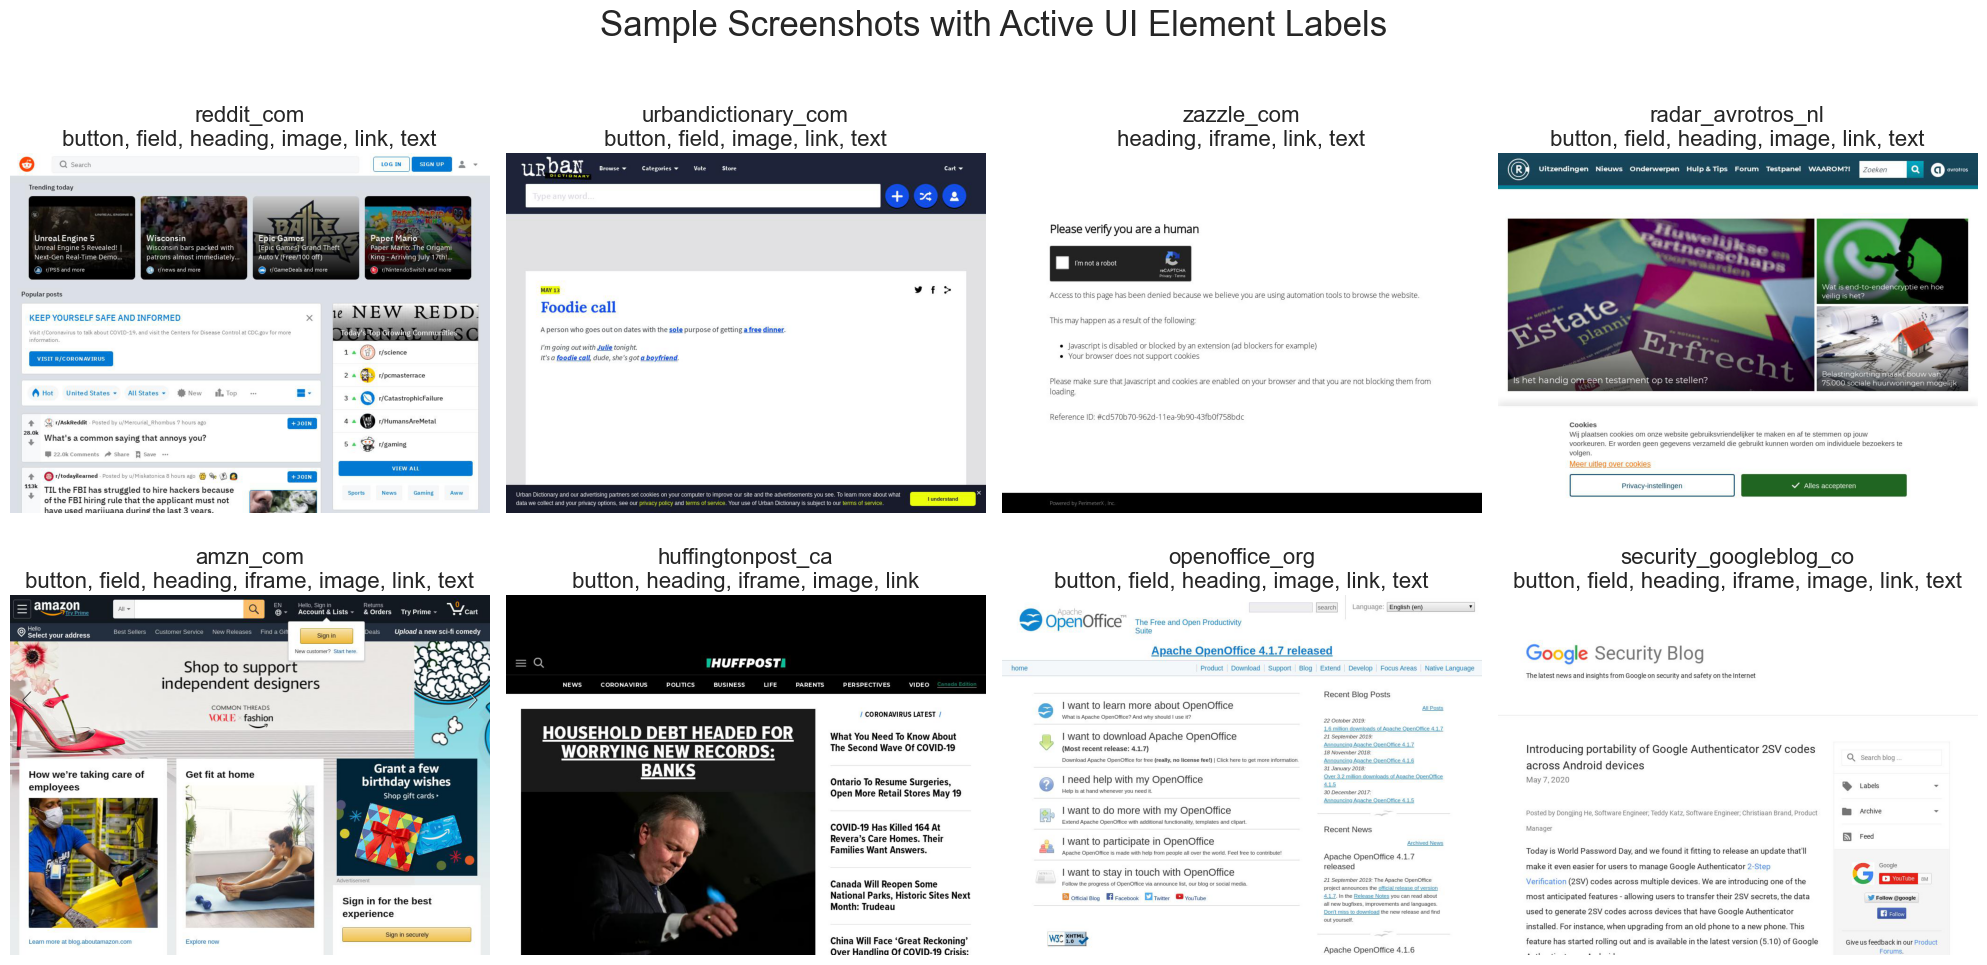

In [19]:
n_samples = 8
sample_df = all_df.sample(n_samples, random_state=RANDOM_SEED) # random pick of the sample from the df

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = Image.open(row['filepath']).convert('RGB') # open image
    active = [c for c in CLASSES if row[c] == 1] # builds a list of only the active labels for this image
    ax.imshow(img)
    ax.set_title(f"{row['domain'][:22]}\n{', '.join(active)}", fontsize=16)
    ax.axis('off')

plt.suptitle('Sample Screenshots with Active UI Element Labels', fontsize=25, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sample_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

The sample grid gives a few examples of the visual diversity of the dataset across 8 randomly selected screenshots. The pages span a wide range of website types like social media feed, e-commerce pages, new sites, dictionaries and others, though most images share the same dominant labels even despite this visual diversity, with `button`, `heading`, `image`, `link` and `text` appearing in nearly every sample, consistent with the class distribution observed earlier.

Some excpetions are encountered in `zazzle_com` that carries `iframe` but no `button`, suggesting a page with embedded third-party content, or `huffingtonpost_ca` that is missing `field` and `text`, showing a news layout where `heading` are more prominant and form inputs are absent. These confirm that while most UI elements are found almost everywhere, the rare classes (`iframe`, `label`, `field`) are yet tied to specific page types and contexts.

## 2. Data Preparation

Before extracting visual features, each screenshot needs to be preprocessed into a format compatible with ResNet50. This involves three steps:

1. **Resizing all images** to 224×224 pixels, that is the input size expected by ResNet50. Since the original screenshots are 1024×768, they need to be scaled down before being used by the network.
2. **Normalizing pixel values** using ImageNet statistics through `preprocess_input`. Pixel values normally range from 0 to 255, but ResNet50 was trained on images that were normalised by substracting the dataset mean for each colour channel. If this step gets skipped, the model gets inputs it wasn't trained on and this can make the extracted ffeatures less reliable.
4. **Extracting embeddings** by passing each image through a pre-trained (frozen) ResNet50 model and taking the 2048-dimensional output from the Global Average Pooling layer. Instead of working with raw 224×224×3 pixel data, this converts each image into a compact vector that represents higher-level features like shapes, textures and layout. These embeddings are much easier for traditional machine learning models to work with.

The embeddings are computed once and saved to disk, while all next steps (EDA, clustering, classification) run on the saved numpy arrays.

I picked ResNet50 because it uses **residual connections**, meaning that it skips connections to allow gradients to flow through 50 layers without vanishing, solving a problem that made very deep networks untrainable before 2015. The model is pretrained on 1.2M ImageNet images, it has already learned to recognise textures, layouts and structural patterns that transfer well to webpage screenshots. 

### 2.1 Feature Extraction via Frozen ResNet50

In [44]:
# Image preprocessing function
def load_and_preprocess(path, target_size=IMG_SIZE):
    """Load an image, resize to 224×224 and apply ResNet50 normalization."""
    img = keras_image.load_img(path, target_size=target_size) # open image and resizes it
    arr = keras_image.img_to_array(img) # converts the PIL image into a numpy array of shape (224, 224, 3)
    return preprocess_input(arr)

# Embedding extraction function
def extract_embeddings(df, model, batch_size=BATCH_SIZE):
    """Pass all images through frozen ResNet50 and return 2048-dim embeddings."""
    embeddings = []
    paths = df['filepath'].tolist()
    # Loops through the paths in steps of 16
    for i in tqdm(range(0, len(paths), batch_size), desc='Extracting'):
        batch = np.stack([load_and_preprocess(p) for p in paths[i:i+batch_size]]) # takes the next 16 paths, preprocesses each one and stacks them into a single array of shape (16, 224, 224, 3)
        embeddings.extend(model.predict(batch, verbose=0)) # passes the batch through ResNet50 and collects 16 embedding vectors of 2048 dimensions each
    return np.array(embeddings)

# Load saved embeddings or extract and save
train_emb_path = os.path.join(EMB_DIR, 'train_embeddings.npy')
valid_emb_path = os.path.join(EMB_DIR, 'valid_embeddings.npy')
test_emb_path = os.path.join(EMB_DIR, 'test_embeddings.npy')

# Chceks if all three files already exist, if yes it skips extraction entirely and just loads them from the disk
if all(os.path.exists(p) for p in [train_emb_path, valid_emb_path, test_emb_path]):
    print("Loading saved embeddings from disk...")
    X_train_emb = np.load(train_emb_path)
    X_valid_emb = np.load(valid_emb_path)
    X_test_emb = np.load(test_emb_path)
else:
    print("Extracting embeddings, runs once then saved...")
    # Loads ResNet50 pretrained on ImageNet
    base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg') # uses pretrained weights, removes the final 1000-class classification layer, applies Global Average Pooling producing one 2048-dim vector per image
    base_model.trainable = False # freezes all weights, the network is uses only as a feature extractor, nothing gets updated
    X_train_emb = extract_embeddings(train_df, base_model)
    X_valid_emb = extract_embeddings(valid_df, base_model)
    X_test_emb = extract_embeddings(test_df,  base_model)
    # Saves the numpy array to disk so next time the if-branch funs instead of recomputing
    np.save(train_emb_path, X_train_emb)
    np.save(valid_emb_path, X_valid_emb)
    np.save(test_emb_path,  X_test_emb)
    print("Embeddings saved to disk.")

print(f"\nTrain embeddings : {X_train_emb.shape}")
print(f"Valid embeddings : {X_valid_emb.shape}")
print(f"Test  embeddings : {X_test_emb.shape}")

Loading saved embeddings from disk...

Train embeddings : (844, 2048)
Valid embeddings : (241, 2048)
Test  embeddings : (121, 2048)


### 2.2 Label Arrays and Class Weights

In [48]:
# Label arrays
y_train = train_df[CLASSES].values.astype(int)
y_valid = valid_df[CLASSES].values.astype(int)
y_test = test_df[CLASSES].values.astype(int)

# Stack the three embedding matrices vertically into one big matrix for EDA, to analyze all images together rather than split by set
X_all_emb = np.vstack([X_train_emb, X_valid_emb, X_test_emb])
y_all = all_df[CLASSES].values.astype(int)

# Class weights
# Rare classes (label, iframe) need higher weight so the classifier doesn't ignore them
print("Class weights (positive class):")
class_weights = {}
# Loops through each of the 8 classes
for i, cls in enumerate(CLASSES):
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train[:, i]) # 'balanced' tells sklearn to automatically calculate weights inversely proportional to class frequency
    class_weights[cls] = {0: round(w[0], 3), 1: round(w[1], 3)} # Stores both weights, for the negative class (0) and the positive class (1)
    print(f"  {cls:10s}: {w[1]:.2f}")

Class weights (positive class):
  button    : 0.52
  field     : 1.05
  heading   : 0.57
  iframe    : 1.94
  image     : 0.52
  label     : 8.61
  link      : 0.65
  text      : 0.51


CClass weights are calculated from the training set to handle the class imbalance we saw earlier. The `balanced` strategy works by giving higher weight to classes that appear less often, and lower weight to classes that appear more often, so rare classes matter more during training and the model doesn’t just learn to ignore them.

The results reflect the imbalance in the dataset:
- `label` gets the highest weight (8.61), meaning each example of this class is treated as much more important during training. This helps the model not overlook it just because it appears rarely.
- `iframe` (1.94) and `field` (1.05) also get slightly higher weights to compensate for their lower frequency.
- Common classes like `text` (0.51), `image` (0.52) and `button` (0.52) get weights below 1 because they appear so often that the model already learns them easily without need needs no boost

These weights will be passed to each classifier during training.







label gets the highest weight (8.61), meaning each example of this class is treated as much more important during training. This helps the model not overlook it just because it appears rarely.
iframe (1.94) and field (1.05) also get slightly higher weights to compensate for their lower frequency.
More common classes like text (0.51), image (0.52), and button (0.52) get weights below 1 because they appear so often that the model already learns them easily without extra emphasis.

These computed weights will be used in each classifier during training to help balance learning across all classes.

## 4. Exploratory Data Analysis

PCA on embeddings
MDS
K-means clustering
NMF on label matrix
Outlier detection (Isolation Forest, LOF)
Hierarchical clustering

## 5. Model Building & Tuning

OneVsRest wrapper
Logistic Regression baseline
SVM, Random Forest, XGBoost
Cross-validated hyperparameter tuning

## 6. Model Evaluation

Hamming loss, micro/macro F1, per-class ROC-AUC
Precision-recall curves

## 7. Interpretation & Insights

Saliency maps
Feature importance per class
Failure case analysis

## 8. Final Discussion

Limitations
Proposed improvements